In [3]:
from pathlib import Path
import re
import gzip

import pandas as pd
import scanpy as sc
import anndata as ad
import scipy.io
import os

os.chdir('c:\\Users\\ankit\\Documents\\scFM\\train_data') 

Ensure paths exist

In [4]:
BASE = Path("GSE192740")
META = BASE / "meta" / "GSE192740_sampleInfo_scRNAseq.tsv"
EXTRACTED = BASE / "extracted"
OUTDIR = BASE / "h5ad"
OUTDIR.mkdir(parents=True, exist_ok=True)

In [5]:
print(BASE, META, EXTRACTED, OUTDIR)

GSE192740 GSE192740\meta\GSE192740_sampleInfo_scRNAseq.tsv GSE192740\extracted GSE192740\h5ad


Load Metadata

In [9]:
meta = pd.read_csv(META, sep="\t")
meta.columns = [c.strip() for c in meta.columns]

print(meta.columns.tolist())
print(meta.head())
print(meta.shape)

['Sample name', 'title', 'source name', 'organism', 'characteristics: shortFileName', 'characteristics: strain', 'characteristics: platform', 'characteristics: digestion method', 'characteristics: number of added ABs', 'characteristics: number of cells', 'molecule', 'description']
                Sample name                                            title  \
0  Whole Liver Nuclei_Mouse  Healthy Mouse Liver Nuclei_Mouse_001_Sample_001   
1  Whole Liver Nuclei_Mouse  Healthy Mouse Liver Nuclei_Mouse_001_Sample_002   
2  Whole Liver Nuclei_Mouse  Healthy Mouse Liver Nuclei_Mouse_001_Sample_003   
3  Whole Liver Nuclei_Mouse  Healthy Mouse Liver Nuclei_Mouse_002_Sample_001   
4  Whole Liver Nuclei_Mouse  Healthy Mouse Liver Nuclei_Mouse_003_Sample_001   

  source name organism characteristics: shortFileName characteristics: strain  \
0       Liver    Mouse                          ABU11                 C57Bl/6   
1       Liver    Mouse                          ABU12                 C57Bl

In [10]:
title_col = "title"
organism_col = "organism"
shortfile_col = "characteristics: shortFileName"

print(meta[[title_col, organism_col, shortfile_col]].head())

                                             title organism  \
0  Healthy Mouse Liver Nuclei_Mouse_001_Sample_001    Mouse   
1  Healthy Mouse Liver Nuclei_Mouse_001_Sample_002    Mouse   
2  Healthy Mouse Liver Nuclei_Mouse_001_Sample_003    Mouse   
3  Healthy Mouse Liver Nuclei_Mouse_002_Sample_001    Mouse   
4  Healthy Mouse Liver Nuclei_Mouse_003_Sample_001    Mouse   

  characteristics: shortFileName  
0                          ABU11  
1                          ABU12  
2                          ABU13  
3                          ABU17  
4                          ABU18  


Filter for Human CD45 and Whole Nuceli

In [11]:
# Print unique values in the title column
print("Unique titles in the dataset:")
print(meta[title_col].unique())

Unique titles in the dataset:
['Healthy Mouse Liver Nuclei_Mouse_001_Sample_001'
 'Healthy Mouse Liver Nuclei_Mouse_001_Sample_002'
 'Healthy Mouse Liver Nuclei_Mouse_001_Sample_003'
 'Healthy Mouse Liver Nuclei_Mouse_002_Sample_001'
 'Healthy Mouse Liver Nuclei_Mouse_003_Sample_001'
 'Healthy Mouse Liver Nuclei_Mouse_002_Sample_002'
 'Healthy Mouse Liver Nuclei_Mouse_004_Sample_001'
 'Healthy Mouse Liver Nuclei_Mouse_003_Sample_002'
 'Healthy Mouse Liver Capsule Nuclei_Mouse_001_Sample_001'
 'Healthy Mouse Liver Nuclei_Mouse_004_Sample_002'
 'Healthy Mouse Liver Nuclei_Mouse_004_Sample_003'
 'Healthy Mouse Liver Nuclei_Mouse_004_Sample_004'
 'Standard diet fed (12 weeks) Liver Myeloid cells_Mouse_001_Sample_001'
 'Standard diet fed (12 weeks) Liver CD45+ cells_Mouse_001_Sample_001'
 'Standard diet fed (12 weeks) Liver CD45+ cells_Mouse_001_Sample_002'
 'Standard diet fed (12 weeks) Liver CD45+ cells_Mouse_001_Sample_003'
 'PBS Oral Gavage, 24hours, Liver CD45+ cells_Mouse_001_Sample_0

In [12]:
meta_human = meta[meta[organism_col].astype(str).str.strip().eq("Human")].copy()

meta_human["sample_class"] = None
meta_human["assay_type"] = None

title_lower = meta_human["Sample name"].astype(str).str.lower()

# CD45+ human liver cells
cd45_mask = title_lower.str.contains("cd45+" , regex=False)

# whole liver nuclei human samples
whole_nuclei_mask = title_lower.str.contains("whole liver nuclei", regex=False)

meta_human.loc[cd45_mask, "sample_class"] = "CD45"
meta_human.loc[cd45_mask, "assay_type"] = "scRNA-seq"

meta_human.loc[whole_nuclei_mask, "sample_class"] = "whole_nuclei"
meta_human.loc[whole_nuclei_mask, "assay_type"] = "snRNA-seq"

meta_target = meta_human.copy()

print(meta_target[[title_col, shortfile_col, "sample_class", "assay_type"]].to_string(index=False))
print("Number of target human samples:", meta_target.shape[0])

                   title characteristics: shortFileName sample_class assay_type
                     H33                           ABU8 whole_nuclei  snRNA-seq
         H02 Abs at 1:30                         CISE06         CD45  scRNA-seq
        H02 Abs at 1:200                         CISE07         CD45  scRNA-seq
        H02 Abs at 1:500                         CISE08         CD45  scRNA-seq
H02 Abs at 1:30 or 1:200                         CISE09         CD45  scRNA-seq
                     H02                           CS31         None       None
                     H02                           CS32         None       None
                     H02                           CS33         None       None
                     H02                           CS34         None       None
                     H04                           CS37         CD45  scRNA-seq
                     H04                           CS38         CD45  scRNA-seq
                     H06                

In [13]:
# Print meta_human to verify the new columns
print(meta_human.head(10))

# Print dimensions of meta_human and meta_target
print("Dimensions of meta_human:", meta_human.shape)


                 Sample name                     title source name organism  \
82  Whole Liver Nuclei_Human                       H33       Liver    Human   
83  Liver_CD45+ Cells_ Human           H02 Abs at 1:30       Liver    Human   
84  Liver_CD45+ Cells_ Human          H02 Abs at 1:200       Liver    Human   
85  Liver_CD45+ Cells_ Human          H02 Abs at 1:500       Liver    Human   
86  Liver_CD45+ Cells_ Human  H02 Abs at 1:30 or 1:200       Liver    Human   
87   Liver CD45- Cells_Human                       H02       Liver    Human   
88           Liver_DCs_Human                       H02       Liver    Human   
89           Liver_DCs_Human                       H02       Liver    Human   
90    Liver_monos+macs_Human                       H02       Liver    Human   
91  Liver_CD45+ Cells_ Human                       H04       Liver    Human   

   characteristics: shortFileName characteristics: strain  \
82                           ABU8                 C57Bl/6   
83      

In [14]:
all_files = [p for p in EXTRACTED.rglob("*") if p.is_file()]
print("Total extracted files:", len(all_files))

for p in all_files[:20]:
    print(p)

Total extracted files: 132
GSE192740\extracted\GSM5764242_filtered_feature_bc_matrix_ABU11.h5
GSE192740\extracted\GSM5764243_filtered_feature_bc_matrix_ABU12.h5
GSE192740\extracted\GSM5764244_filtered_feature_bc_matrix_ABU13.h5
GSE192740\extracted\GSM5764245_filtered_feature_bc_matrix_ABU17.h5
GSE192740\extracted\GSM5764246_filtered_feature_bc_matrix_ABU18.h5
GSE192740\extracted\GSM5764247_filtered_feature_bc_matrix_ABU19.h5
GSE192740\extracted\GSM5764248_filtered_feature_bc_matrix_ABU1.h5
GSE192740\extracted\GSM5764249_filtered_feature_bc_matrix_ABU20.h5
GSE192740\extracted\GSM5764250_filtered_feature_bc_matrix_ABU21.h5
GSE192740\extracted\GSM5764251_filtered_feature_bc_matrix_ABU2.h5
GSE192740\extracted\GSM5764252_filtered_feature_bc_matrix_ABU7.h5
GSE192740\extracted\GSM5764253_filtered_feature_bc_matrix_ABU9.h5
GSE192740\extracted\GSM5764254_filtered_feature_bc_matrix_ARE1.txt.gz
GSE192740\extracted\GSM5764255_filtered_feature_bc_matrix_ARE6.txt.gz
GSE192740\extracted\GSM5764256_fi

In [15]:
short_to_files = {}

for short_name in meta_target[shortfile_col].astype(str).unique():
    matched = [p for p in all_files if short_name in p.name or short_name in str(p)]
    short_to_files[short_name] = sorted(matched)

for short_name in list(short_to_files.keys())[:10]:
    print(f"\n{short_name}")
    for f in short_to_files[short_name][:5]:
        print("   ", f)

print(len(short_to_files.keys()))


ABU8
    GSE192740\extracted\GSM5764336_filtered_feature_bc_matrix_ABU8.h5

CISE06
    GSE192740\extracted\GSM5764338_filtered_feature_bc_matrix_CISE06.txt.gz

CISE07
    GSE192740\extracted\GSM5764341_filtered_feature_bc_matrix_CISE07.txt.gz

CISE08
    GSE192740\extracted\GSM5764344_filtered_feature_bc_matrix_CISE08.txt.gz

CISE09
    GSE192740\extracted\GSM5764346_filtered_feature_bc_matrix_CISE09.txt.gz

CS31
    GSE192740\extracted\GSM5764349_filtered_feature_bc_matrix_CS31.h5

CS32
    GSE192740\extracted\GSM5764351_filtered_feature_bc_matrix_CS32.h5

CS33
    GSE192740\extracted\GSM5764354_filtered_feature_bc_matrix_CS33.h5

CS34
    GSE192740\extracted\GSM5764356_filtered_feature_bc_matrix_CS34.h5

CS37
    GSE192740\extracted\GSM5764358_filtered_feature_bc_matrix_CS37.h5
38


In [16]:
import gzip
import scipy.io
import anndata as ad
import scanpy as sc
import pandas as pd

def read_10x_h5_file(path):
    adata = sc.read_10x_h5(str(path))
    adata.var_names_make_unique()
    return adata

def read_table_maybe_gz(path):
    if str(path).endswith(".gz"):
        with gzip.open(path, "rt") as fh:
            return pd.read_csv(fh, sep="\t", header=None)
    return pd.read_csv(path, sep="\t", header=None)

def find_mtx_bundle(files):
    matrix = None
    barcodes = None
    features = None

    for f in files:
        name = f.name.lower()
        if "matrix.mtx" in name:
            matrix = f
        elif "barcodes.tsv" in name:
            barcodes = f
        elif "features.tsv" in name or "genes.tsv" in name:
            features = f

    return matrix, barcodes, features

def read_mtx_bundle(matrix_path, barcodes_path, features_path):
    if str(matrix_path).endswith(".gz"):
        with gzip.open(matrix_path, "rt") as fh:
            X = scipy.io.mmread(fh).tocsr().T
    else:
        X = scipy.io.mmread(str(matrix_path)).tocsr().T

    barcodes = read_table_maybe_gz(barcodes_path)
    features = read_table_maybe_gz(features_path)

    obs = pd.DataFrame(index=barcodes.iloc[:, 0].astype(str))

    if features.shape[1] >= 2:
        var = pd.DataFrame(index=features.iloc[:, 1].astype(str))
        var["gene_ids"] = features.iloc[:, 0].astype(str).values
    else:
        var = pd.DataFrame(index=features.iloc[:, 0].astype(str))

    adata = ad.AnnData(X=X, obs=obs, var=var)
    adata.var_names_make_unique()
    return adata

Load one sample

In [17]:
def load_one_sample(row):
    short_name = str(row[shortfile_col])
    files = short_to_files.get(short_name, [])

    if not files:
        print(f"[WARN] No files found for shortFileName={short_name}")
        return None

    # 1) Prefer H5
    h5_files = [f for f in files if f.name.lower().endswith(".h5")]
    if h5_files:
        chosen = h5_files[0]
        print(f"{short_name}: reading H5 -> {chosen.name}")
        adata = read_10x_h5_file(chosen)

    else:
        # 2) Try MTX bundle
        matrix, barcodes, features = find_mtx_bundle(files)
        if matrix and barcodes and features:
            print(f"{short_name}: reading MTX bundle")
            adata = read_mtx_bundle(matrix, barcodes, features)

        else:
            # 3) Try single txt.gz matrix
            txt_gz_files = [f for f in files if f.name.lower().endswith(".txt.gz")]
            if txt_gz_files:
                chosen = txt_gz_files[0]
                print(f"{short_name}: reading TXT.GZ -> {chosen.name}")
                adata = read_single_txt_gz_matrix(chosen)
            else:
                print(f"[WARN] Could not resolve readable files for shortFileName={short_name}")
                for f in files:
                    print("   ", f)
                return None

    # Add metadata
    for col in row.index:
        adata.obs[col] = str(row[col])

    adata.obs["shortFileName"] = short_name
    adata.obs["assay_type"] = str(row["assay_type"])
    adata.obs["sample_class"] = str(row["sample_class"])
    adata.obs["sample_group"] = adata.obs["sample_class"]

    # make cell names unique across samples
    adata.obs_names = [f"{short_name}_{bc}" for bc in adata.obs_names]
    adata.obs_names_make_unique()
    adata.var_names_make_unique()

    return adata

Loading .txt.gz files

In [18]:
import pandas as pd
import anndata as ad

def read_single_txt_gz_matrix(path):
    """
    Read a single filtered_feature_bc_matrix_<short>.txt.gz file.

    Expected structure:
    - tab-delimited
    - first column = gene name / gene id
    - remaining columns = cell barcodes
    - rows = genes
    """
    print(f"Reading TXT.GZ matrix -> {path.name}")

    df = pd.read_csv(path, sep="\t", compression="gzip", header=0)

    # first column is gene identifier
    gene_col = df.columns[0]

    # set gene names as index BEFORE transpose
    expr = df.set_index(gene_col)

    # now transpose so rows=cells, cols=genes
    X = expr.T

    # make sure both axes are strings
    X.index = X.index.astype(str)
    X.columns = X.columns.astype(str)

    obs = pd.DataFrame(index=X.index)
    var = pd.DataFrame(index=X.columns)
    var["feature_name"] = X.columns.astype(str)

    adata = ad.AnnData(X=X, obs=obs, var=var)
    adata.obs_names_make_unique()
    adata.var_names_make_unique()

    return adata

Load all samples

In [48]:

print(meta_target.__len__())
h_ids = ["H04", "H10", "H14", "H22", "H23", "H25", "H30", "H32", "H33", "H37", "H38"]
# Filter meta_target to only rows where the title contains one of the h_ids
meta_target = meta_target[meta_target[title_col].astype(str).str.contains("|".join(h_ids), regex=True)]

print(meta_target.__len__())

20
18


In [49]:
adatas = []

for _, row in meta_target.sort_values([ "sample_class", shortfile_col ]).iterrows():
    a = load_one_sample(row)
    if a is not None:
        adatas.append(a)

print("Loaded sample objects:", len(adatas))

CS110: reading H5 -> GSM5764389_filtered_feature_bc_matrix_CS110.h5


c:\Users\ankit\miniconda3\envs\scanpy\Lib\site-packages\anndata\_core\anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


CS112: reading H5 -> GSM5764391_filtered_feature_bc_matrix_CS112.h5


c:\Users\ankit\miniconda3\envs\scanpy\Lib\site-packages\anndata\_core\anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


CS126: reading H5 -> GSM5764392_filtered_feature_bc_matrix_CS126.h5


...

c:\Users\ankit\miniconda3\envs\scanpy\Lib\site-packages\anndata\_core\anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


CS171: reading H5 -> GSM5764401_filtered_feature_bc_matrix_CS171.h5


c:\Users\ankit\miniconda3\envs\scanpy\Lib\site-packages\anndata\_core\anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
c:\Users\ankit\miniconda3\envs\scanpy\Lib\site-packages\anndata\_core\anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


CS111: reading H5 -> GSM5764390_filtered_feature_bc_matrix_CS111.h5
CS127: reading H5 -> GSM5764393_filtered_feature_bc_matrix_CS127.h5
Loaded sample objects: 18


c:\Users\ankit\miniconda3\envs\scanpy\Lib\site-packages\anndata\_core\anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [50]:
print("Loaded sample objects:", len(adatas))

Loaded sample objects: 18


In [51]:
# View the varnames of each adata objects to see if they look like gene names or gene ids
for i, ad in enumerate(adatas):
    print(f"Ad {i} var_names sample:", ad.var_names[:5])
    print("")


Ad 0 var_names sample: Index(['MIR1302-10', 'FAM138A', 'OR4F5', 'RP11-34P13.7', 'RP11-34P13.8'], dtype='object')

Ad 1 var_names sample: Index(['MIR1302-10', 'FAM138A', 'OR4F5', 'RP11-34P13.7', 'RP11-34P13.8'], dtype='object')

Ad 2 var_names sample: Index(['MIR1302-10', 'FAM138A', 'OR4F5', 'RP11-34P13.7', 'RP11-34P13.8'], dtype='object')

Ad 3 var_names sample: Index(['MIR1302-10', 'FAM138A', 'OR4F5', 'RP11-34P13.7', 'RP11-34P13.8'], dtype='object')

Ad 4 var_names sample: Index(['MIR1302-10', 'FAM138A', 'OR4F5', 'RP11-34P13.7', 'RP11-34P13.8'], dtype='object')

Ad 5 var_names sample: Index(['MIR1302-10', 'FAM138A', 'OR4F5', 'RP11-34P13.7', 'RP11-34P13.8'], dtype='object')

Ad 6 var_names sample: Index(['MIR1302-10', 'FAM138A', 'OR4F5', 'RP11-34P13.7', 'RP11-34P13.8'], dtype='object')

Ad 7 var_names sample: Index(['MIR1302-10', 'FAM138A', 'OR4F5', 'RP11-34P13.7', 'RP11-34P13.8'], dtype='object')

Ad 8 var_names sample: Index(['MIR1302-10', 'FAM138A', 'OR4F5', 'RP11-34P13.7', 'RP11-34

Combine into one adata

In [58]:
# Combine the adata objects into one anndata object
adata = sc.concat(adatas, axis=0, join="outer", label="gsm_id", index_unique="-")

In [59]:
print(adata.obs.head())

                                         Sample name title source name  \
CS110_AAACCCAAGGTATCTC-1-0  Liver_CD45+ Cells_ Human   H22       Liver   
CS110_AAACCCACACGGTGTC-1-0  Liver_CD45+ Cells_ Human   H22       Liver   
CS110_AAACCCACAGCTGAGA-1-0  Liver_CD45+ Cells_ Human   H22       Liver   
CS110_AAACCCACAGTCAGTT-1-0  Liver_CD45+ Cells_ Human   H22       Liver   
CS110_AAACCCACATTGCAAC-1-0  Liver_CD45+ Cells_ Human   H22       Liver   

                           organism characteristics: shortFileName  \
CS110_AAACCCAAGGTATCTC-1-0    Human                          CS110   
CS110_AAACCCACACGGTGTC-1-0    Human                          CS110   
CS110_AAACCCACAGCTGAGA-1-0    Human                          CS110   
CS110_AAACCCACAGTCAGTT-1-0    Human                          CS110   
CS110_AAACCCACATTGCAAC-1-0    Human                          CS110   

                           characteristics: strain characteristics: platform  \
CS110_AAACCCAAGGTATCTC-1-0                     nan    

Check Metadata

In [60]:
print(adata.obs[["shortFileName", "title", "assay_type", "sample_class"]].head())

print("\nassay_type counts:")
print(adata.obs["assay_type"].value_counts(dropna=False))

print("\nsample_class counts:")
print(adata.obs["sample_class"].value_counts(dropna=False))

                           shortFileName title assay_type sample_class
CS110_AAACCCAAGGTATCTC-1-0         CS110   H22  scRNA-seq         CD45
CS110_AAACCCACACGGTGTC-1-0         CS110   H22  scRNA-seq         CD45
CS110_AAACCCACAGCTGAGA-1-0         CS110   H22  scRNA-seq         CD45
CS110_AAACCCACAGTCAGTT-1-0         CS110   H22  scRNA-seq         CD45
CS110_AAACCCACATTGCAAC-1-0         CS110   H22  scRNA-seq         CD45

assay_type counts:
assay_type
snRNA-seq    47019
scRNA-seq    45969
None          9016
Name: count, dtype: int64

sample_class counts:
sample_class
whole_nuclei    47019
CD45            45969
None             9016
Name: count, dtype: int64


Cleanup

In [61]:
for col in ["shortFileName", "assay_type", "sample_class", "sample_group", "title", "organism"]:
    if col in adata.obs.columns:
        adata.obs[col] = adata.obs[col].astype(str)

adata.obs_names_make_unique()
adata.var_names_make_unique()

In [62]:
out_file = OUTDIR / "GSE192740_human_CD45plus_and_whole_nuclei.h5ad"
adata.write_h5ad(out_file, compression="gzip")
print(f"Saved to: {out_file}")

Saved to: GSE192740\h5ad\GSE192740_human_CD45plus_and_whole_nuclei.h5ad


Read in saved adata

In [64]:
# Read in saved adata
out_file = OUTDIR / "GSE192740_human_CD45plus_and_whole_nuclei.h5ad"
adata2 = sc.read_h5ad(out_file)
print(adata2)

AnnData object with n_obs × n_vars = 102004 × 32738
    obs: 'Sample name', 'title', 'source name', 'organism', 'characteristics: shortFileName', 'characteristics: strain', 'characteristics: platform', 'characteristics: digestion method', 'characteristics: number of added ABs', 'characteristics: number of cells', 'molecule', 'description', 'sample_class', 'assay_type', 'shortFileName', 'sample_group', 'gsm_id'


In [7]:
# View the first few entries of characteristics obs columns
print("\nFirst few entries in obs:")
print(adata2.obs.head())

# View unique entries of organism column
print("\nUnique organisms in the dataset:")
print(adata2.obs['title'].unique())


First few entries in obs:
                Sample name            title source name organism  \
0  Liver_CD45+ Cells_ Human  H02 Abs at 1:30       Liver    Human   
1  Liver_CD45+ Cells_ Human  H02 Abs at 1:30       Liver    Human   
2  Liver_CD45+ Cells_ Human  H02 Abs at 1:30       Liver    Human   
3  Liver_CD45+ Cells_ Human  H02 Abs at 1:30       Liver    Human   
4  Liver_CD45+ Cells_ Human  H02 Abs at 1:30       Liver    Human   

  characteristics: shortFileName characteristics: strain  \
0                         CISE06                     nan   
1                         CISE06                     nan   
2                         CISE06                     nan   
3                         CISE06                     nan   
4                         CISE06                     nan   

  characteristics: platform characteristics: digestion method  \
0         10x Genomics – v2                           Ex Vivo   
1         10x Genomics – v2                           Ex Vivo   
2 

In [8]:
print("shape:", adata2.shape)

print("\nvar columns:")
print(adata2.var.columns.tolist())

print("\nFirst 10 var_names:")
print(adata2.var_names[:10])

print("\nFirst 10 rows of adata2.var:")
print(adata2.var.head(10))

shape: (272857, 66609)

var columns:
[]

First 10 var_names:
Index(['0', '0-1', '0-10', '0-100', '0-1000', '0-10000', '0-10001', '0-10002',
       '0-10003', '0-10004'],
      dtype='object')

First 10 rows of adata2.var:
Empty DataFrame
Columns: []
Index: [0, 0-1, 0-10, 0-100, 0-1000, 0-10000, 0-10001, 0-10002, 0-10003, 0-10004]


Read in the extra metadata csv

In [11]:
# Read in extra metadata csv
extra_meta_path = BASE / "meta" / "fixed_patient_table.csv"
extra_meta = pd.read_csv(extra_meta_path)
print(extra_meta.head())


  Sample_Number_Flow           Biopsy_used_for   Gender      Age   Weight  \
0                H01             Flow Cytometry    male  unknown  unknown   
1                H02   CITE-Seq; Flow Cytometry    male  unknown  unknown   
2                H03             Flow Cytometry    male  unknown  unknown   
3                H04  scRNA-seq; Flow Cytometry  female      53y     73kg   
4                H05             Flow Cytometry    male      56y     79kg   

    Height                         Reason_for_hospitalization  \
0  unknown                                            unknown   
1  unknown            Colorectal cancer with liver metastases   
2  unknown                                    Liver resection   
3    161cm                    Symptomatic cholecystolithiasis   
4    176cm  Colorectal cancer with synchronous multiple li...   

                                 Procedure  \
0                                  unknown   
1                          Liver resection   
2       

In [15]:
import re

# Extract sample number from 'title' column (e.g., 'H02' from 'H02 Abs at 1:30')
adata2.obs['sample_number'] = adata2.obs['title'].str.extract(r'(H\d+)')

# Merge extra_meta with adata2.obs on sample_number and Sample_Number_Flow
adata2.obs = adata2.obs.merge(extra_meta, left_on='sample_number', right_on='Sample_Number_Flow', how='left', suffixes=('', '_extra'))

# Check how many cells have matching sample metadata
print("Number of cells with matched sample metadata:")
print(adata2.obs['sample_number'].notna().sum())

# Print unique sample numbers in adata2.obs
print("\nUnique sample numbers in adata2.obs:")
print(adata2.obs['sample_number'].unique())

# Optionally, drop the temporary sample_number column if not needed
# adata2.obs.drop('sample_number', axis=1, inplace=True)

# Print the new columns added from extra_meta
new_cols = [col for col in adata2.obs.columns if col.endswith('_extra') or col in extra_meta.columns]
print("\nNew or merged columns from extra_meta:")
print(new_cols)

Number of cells with matched sample metadata:
272857

Unique sample numbers in adata2.obs:
['H02' 'H18' 'H21' 'H22' 'H23' 'H25' 'H04' 'H06' 'H07' 'H10' 'H11' 'H13'
 'H14' 'H16' 'H33' 'H30' 'H32' 'H37' 'H38']

New or merged columns from extra_meta:
['Sample_Number_Flow', 'Biopsy_used_for ', 'Gender', 'Age', 'Weight', 'Height', 'Reason_for_hospitalization', 'Procedure', 'Concomitant_medication', 'Concomitant_disorders_operations', 'Alcohol_intake', 'Steatosis', 'Fibrosis']


c:\Users\ankit\miniconda3\envs\scanpy\Lib\functools.py:982: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


In [17]:
print(adata2)

AnnData object with n_obs × n_vars = 272857 × 66609
    obs: 'Sample name', 'title', 'source name', 'organism', 'characteristics: shortFileName', 'characteristics: strain', 'characteristics: platform', 'characteristics: digestion method', 'characteristics: number of added ABs', 'characteristics: number of cells', 'molecule', 'description', 'sample_class', 'assay_type', 'shortFileName', 'sample_group', 'batch', 'sample_number', 'Sample_Number_Flow', 'Biopsy_used_for ', 'Gender', 'Age', 'Weight', 'Height', 'Reason_for_hospitalization', 'Procedure', 'Concomitant_medication', 'Concomitant_disorders_operations', 'Alcohol_intake', 'Steatosis', 'Fibrosis'
    uns: 'description', 'source_series'


Plots to confirm the data is not filtered

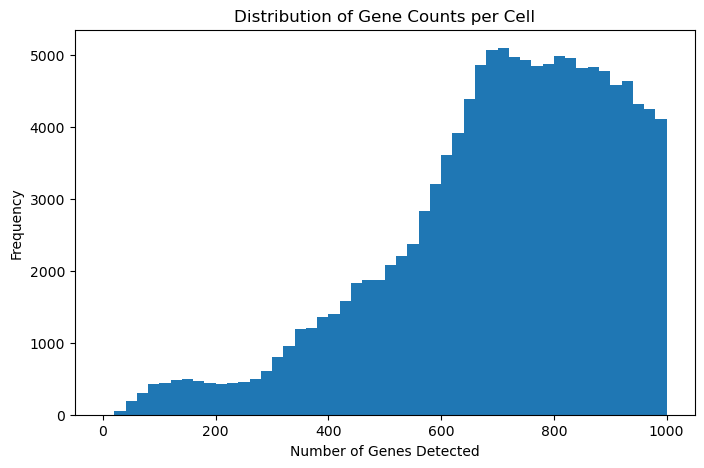

In [37]:
# Plot histogram of number of genes detected per cell in range 0 - 1000
import matplotlib.pyplot as plt
adata.obs["n_genes"] = (adata.X > 0).sum(axis=1).A1
plt.figure(figsize=(8, 5))
plt.hist(adata.obs["n_genes"], bins=50, range=(0, 1000))
plt.xlabel("Number of Genes Detected")
plt.ylabel("Frequency")
plt.title("Distribution of Gene Counts per Cell")
plt.show()



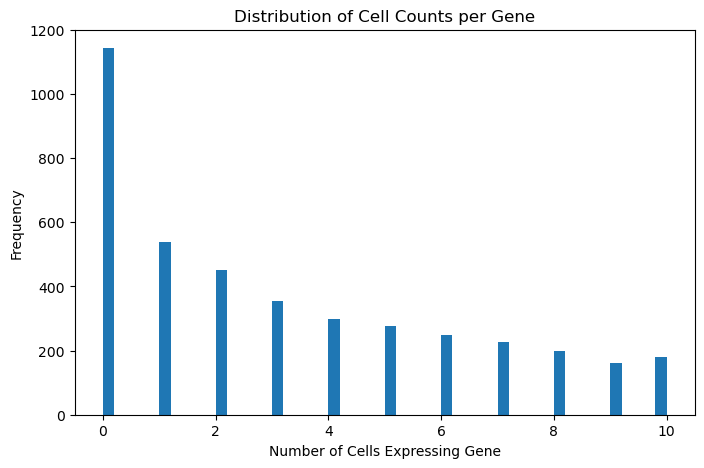

In [40]:
# Plot histogram of cell counts per gene in range 0 - 100
adata.var["n_cells"] = (adata.X > 0).sum(axis=0).A1
plt.figure(figsize=(8, 5))  
plt.hist(adata.var["n_cells"], bins=50, range=(0, 10))
plt.xlabel("Number of Cells Expressing Gene")
plt.ylabel("Frequency")
plt.title("Distribution of Cell Counts per Gene")
plt.show()


OLD CODE

In [49]:
#Rename MASH to MASH w Cirrhosis
adata.obs['disease'] = adata.obs['disease'].replace({'MASH': 'MASH w Cirrhosis'})

#Print the updated unique values in 'disease' column
print("\nUpdated unique values in 'disease' column:")
print(adata.obs['disease'].unique())


Updated unique values in 'disease' column:
['ND' 'MASH w Cirrhosis']


In [50]:
# Add a assay_type column to adata.obs
adata.obs['assay_type'] = 'scRNA-seq'

In [51]:
# Save the processed AnnData object for future use
adata.write("GSE270488_processed.h5ad")

In [54]:
# View sample of adata transcriptomic data
print(adata.X[:100, :100])

# View assay type column head
print(adata.obs['assay_type'].head())

<Compressed Sparse Column sparse matrix of dtype 'float64'
	with 370 stored elements and shape (100, 100)>
  Coords	Values
  (27, 6)	1.6668635681486232
  (69, 16)	1.6037026728803543
  (72, 16)	1.247431518155778
  (74, 16)	1.1829473332153773
  (75, 16)	0.9894519904056397
  (11, 17)	0.9017513483943169
  (54, 17)	1.1497797211260308
  (65, 17)	1.497885426528353
  (73, 17)	1.2376148999277883
  (5, 24)	0.6847541419056519
  (9, 24)	1.039624048151085
  (11, 24)	0.9017513483943169
  (23, 24)	1.0850647975023702
  (31, 24)	0.8108607780405805
  (37, 24)	0.8344778928487593
  (40, 24)	2.018551708457756
  (47, 24)	1.8047941742342448
  (50, 24)	1.5379356293417232
  (53, 24)	1.04712754119977
  (62, 24)	0.7411838598262165
  (66, 24)	1.1277032533786588
  (71, 24)	2.1015394369183102
  (85, 24)	1.6682587417447567
  (92, 24)	2.0547691313352106
  (95, 24)	1.1848351091483489
  :	:
  (11, 97)	0.9017513483943169
  (13, 97)	0.9168911521863988
  (17, 97)	1.9249492734632614
  (19, 97)	1.2890957308953186
  (23, 97)